# Superstore Sales & Profit Analysis

## Objective

## Analyze Superstore sales data to understand sales, profitability,
## customers, products, regions, and discount patterns

## The goal is to identify important business trends and provide
## data-driven recommendations

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

## 1. Load Dataset

In [3]:
df = pd.read_csv("Sample - Superstore.csv" , encoding="latin1")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Data Understanding

In [6]:
df.shape

(9994, 21)

In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [12]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 3. Data Quality Check

In [14]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [37]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [38]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [39]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [40]:
df["Order Date"].dtype
df["Ship Date"].dtype

dtype('<M8[us]')

In [41]:
df["Sales"].describe()
# minimum sales = $0.444
# maximum sales = $22638.480

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64

## top 10 highest sales

In [42]:
df.nlargest(10, "Sales")["Sales"]

2697    22638.480
6826    17499.950
8153    13999.960
2623    11199.968
4190    10499.970
9039     9892.740
4098     9449.950
4277     9099.930
8488     8749.950
6425     8399.976
Name: Sales, dtype: float64

## To find the row with the highest Sales 

In [43]:
df.loc[df["Sales"].idxmax()]

Row ID                                                        2698
Order ID                                            CA-2014-145317
Order Date                                     2014-03-18 00:00:00
Ship Date                                      2014-03-23 00:00:00
Ship Mode                                           Standard Class
Customer ID                                               SM-20320
Customer Name                                          Sean Miller
Segment                                                Home Office
Country                                              United States
City                                                  Jacksonville
State                                                      Florida
Postal Code                                                  32216
Region                                                       South
Product ID                                         TEC-MA-10002412
Category                                                Techno

## The company made $22,638,48 in sales,but  actually  lost  about  $1,811.08  on  this  order.
## The company might be selling some products at high revenue but still losing money because of things like large discounts or high costs.
## Discount = 0.5 That's a 50% discount.

In [46]:
df["Profit"].describe()

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

In [48]:
df.nsmallest(10 , "Profit")["Profit"]

7772   -6599.9780
683    -3839.9904
9774   -3701.8928
3011   -3399.9800
4991   -2929.4845
3151   -2639.9912
5310   -2287.7820
9639   -1862.3124
1199   -1850.9464
2697   -1811.0784
Name: Profit, dtype: float64

In [50]:
df.loc[df["Profit"].idxmin()]

Row ID                                                7773
Order ID                                    CA-2016-108196
Order Date                             2016-11-25 00:00:00
Ship Date                              2016-12-02 00:00:00
Ship Mode                                   Standard Class
Customer ID                                       CS-12505
Customer Name                                Cindy Stewart
Segment                                           Consumer
Country                                      United States
City                                             Lancaster
State                                                 Ohio
Postal Code                                          43130
Region                                                East
Product ID                                 TEC-MA-10000418
Category                                        Technology
Sub-Category                                      Machines
Product Name     Cubify CubeX 3D Printer Double Head Pri

## The dataset says that the company sold 5 printers with 70% of discount which lead to very high loss high discount is the reason of the loss

In [52]:
df["Discount"].value_counts().sort_index()

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

## This means 
##  66 orders were at 50% discount
##  138 orders were at 60% discount
##  418 orders were at 70% discount
##  300 orders were at 80% discount

In [53]:
df["Sales"].sum()

np.float64(2297200.8603)

## 9,994 orders with the sales of $2297200.8603

In [54]:
df["Profit"].sum()

np.float64(286397.0217)

## Total profit is $286397.0217

## 5. Key Performance Indicators

In [57]:
profit_margin = (df["Profit"].sum()/df["Sales"].sum())*100
profit_margin

np.float64(12.467217240315605)

## For every 100 of sales, the company made approximately 12.47 dollar profit.

## 6. Category Analysis

In [58]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

## Technology has the most sales with $836154.0330 
## followed by Furniture with 741999.7953 then Office Supplies 719047.0320

In [61]:
category_profit_margin = (df.groupby("Category")["Profit"].sum()/df.groupby("Category")["Sales"].sum())*100
category_profit_margin 

Category
Furniture           2.486695
Office Supplies    17.035158
Technology         17.395712
dtype: float64

## For every 100 dollar of Furniture sales, the company makes about $2.49 profit
## For every 100 dollar of Office Supplies sales, the company makes about $17.04 profit
## For every 100 dollar of Technology sales, the company makes about $17.40 profit

In [62]:
category_sales = df.groupby("Category")["Sales"].sum()

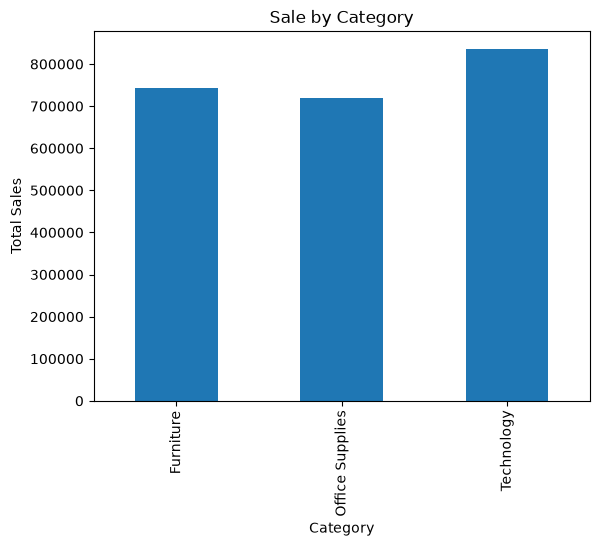

In [65]:
category_sales.plot(kind="bar")
plt.title("Sale by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

In [66]:
category_profit = df.groupby("Category")["Profit"].sum()

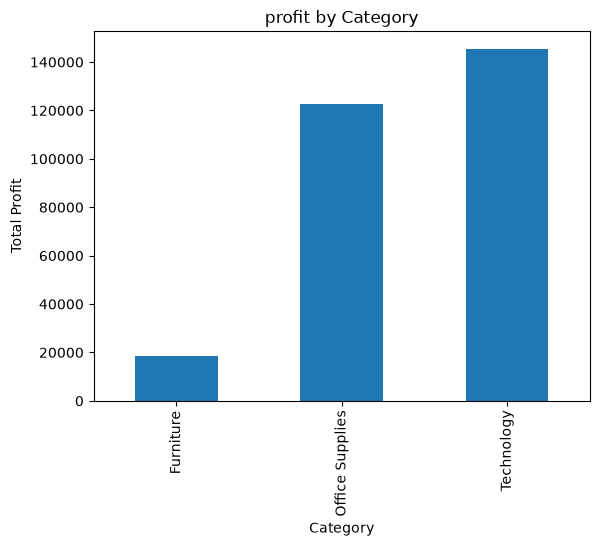

In [67]:
category_profit.plot(kind="bar")
plt.title("profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

## 7. Region Analysis

In [68]:
region_sales = df.groupby("Region")["Sales"].sum()
region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

In [69]:
region_sales.idxmax()

'West'

## Region with highest sales 

In [80]:
region_sales.max()

np.float64(725457.8245)

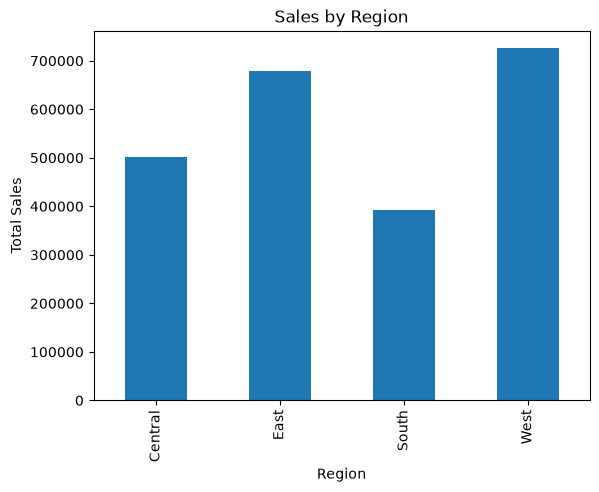

In [71]:
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

## 8. Time Analysis

In [72]:
df["Year"] = df["Order Date"].dt.year

In [73]:
df[["Order Date", "Year"]].head()

,Order Date,Year
0,2016-11-08,2016
1,2016-11-08,2016
2,2016-06-12,2016
3,2015-10-11,2015
4,2015-10-11,2015


In [74]:
yearly_sales = df.groupby("Year")["Sales"].sum()
yearly_sales

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

In [78]:
yearly_sales.idxmax()

np.int32(2017)

## Highest sales is in 2017

In [79]:
yearly_sales.max()

np.float64(733215.2552)

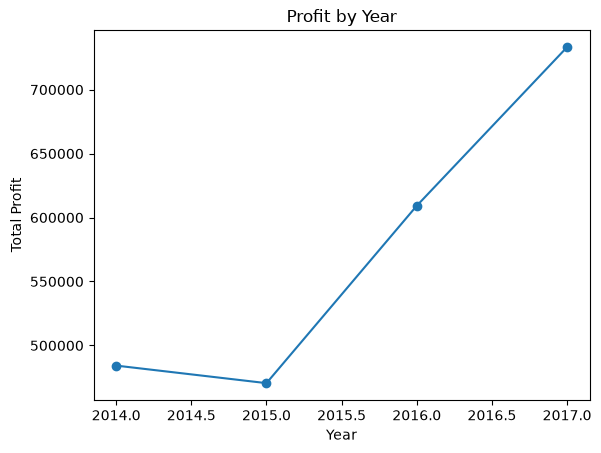

In [82]:
yearly_sales.plot(kind="line",marker="o")
plt.title("Profit by Year")
plt.xlabel("Year")
plt.ylabel("Total Profit")
plt.show()

## Profit declined slightly in 2015 but then increased consistently through 2017

In [84]:
df["Month"] = df["Order Date"].dt.month

In [87]:
df[["Order Date", "Month"]].head()

,Order Date,Month
0,2016-11-08,11
1,2016-11-08,11
2,2016-06-12,6
3,2015-10-11,10
4,2015-10-11,10


In [85]:
monthly_sales = df.groupby("Month")["Sales"].sum()

In [86]:
monthly_sales

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

In [89]:
monthly_sales.idxmax()

np.int32(11)

In [90]:
monthly_sales.max()

np.float64(352461.071)

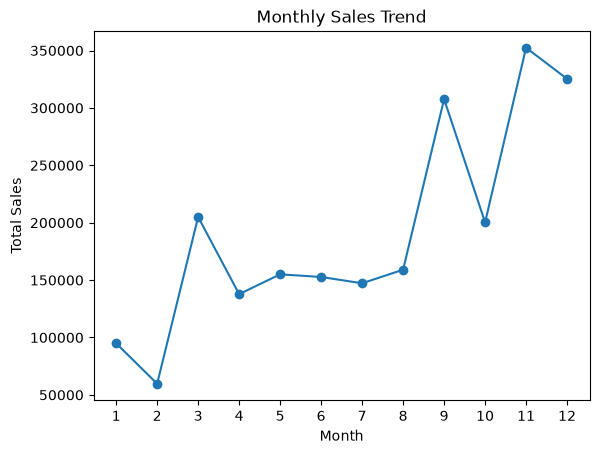

In [93]:
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.show()

## February lowest sales
## September big increase in sales
## November highest sales
## December also very high sales

## 9. Product Analysis

In [95]:
product_sales = df.groupby("Product Name")["Sales"].sum()

In [98]:
top_products = product_sales.sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

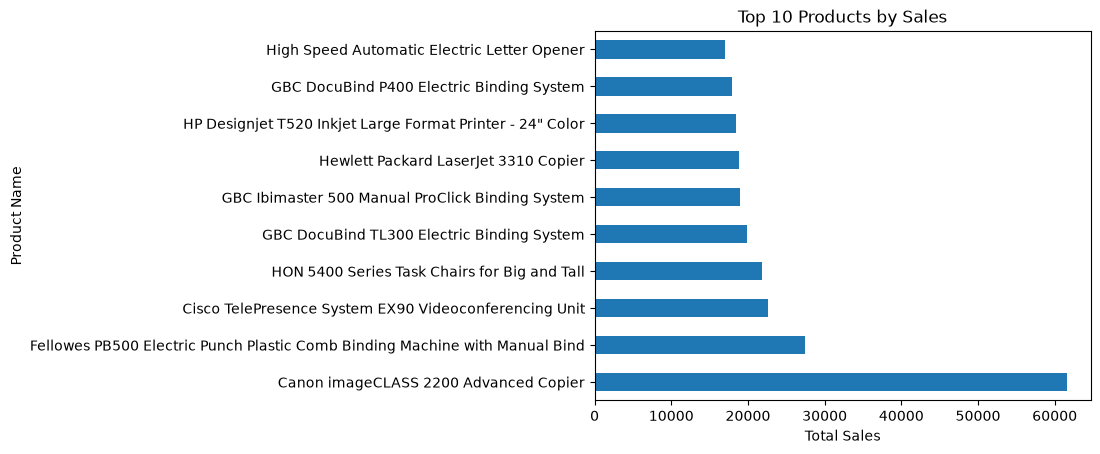

In [100]:
top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

In [101]:
bottom_products = product_sales.sort_values(ascending=True).head(10)
bottom_products

Product Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Newell 308                                                          8.400
Name: Sales, dtype: float64

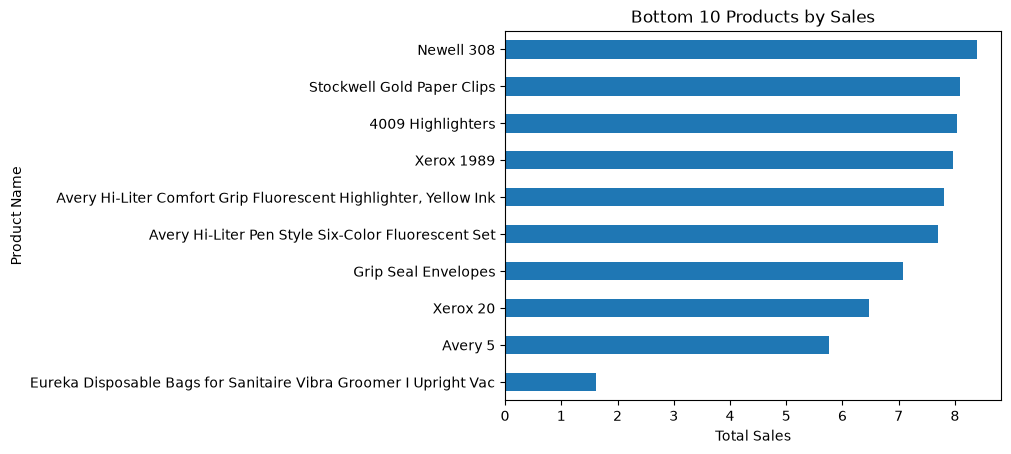

In [102]:
bottom_products.plot(kind="barh")
plt.title("Bottom 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

## 10. Customer Analysis

In [103]:
customer_sales = df.groupby("Customer Name")["Sales"].sum()

In [105]:
top_customers = customer_sales.sort_values(ascending=False).head(10)
top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

<Axes: ylabel='Customer Name'>

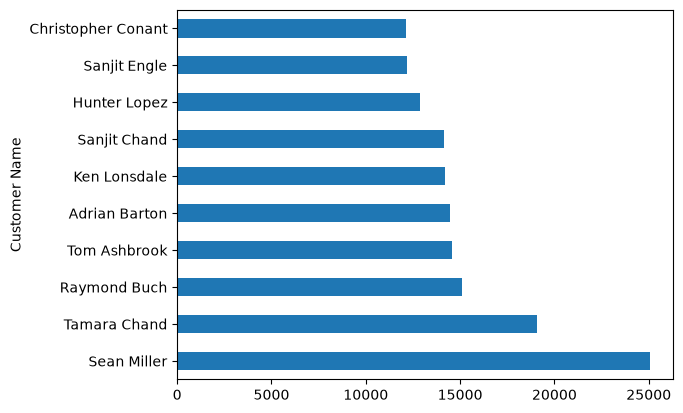

In [108]:
top_customers.plot(kind="barh")

In [ ]:
## 11. Discount Analysis

In [109]:
customer_profit = df.groupby("Customer Name")["Profit"].sum()

In [111]:
top_profit_customers = customer_profit.sort_values(ascending=False).head(10)
top_profit_customers

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

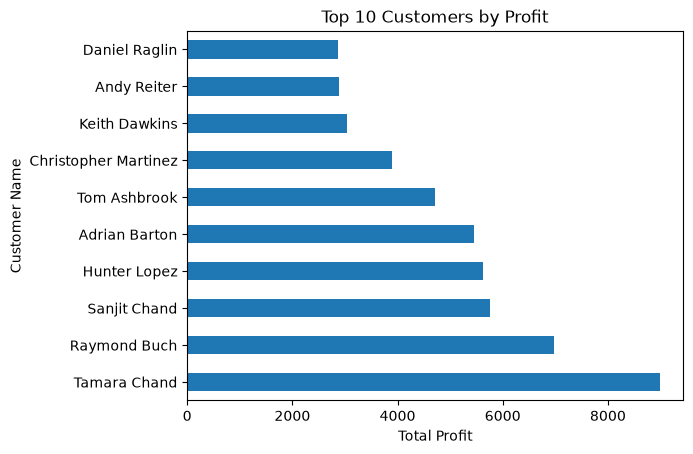

In [112]:
top_profit_customers.plot(kind="barh")
plt.title("Top 10 Customers by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Customer Name")
plt.show()

## Customer Segment Analysis

In [114]:
segment_sales = df.groupby("Segment")["Sales"].sum()
segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

In [115]:
segment_sales.idxmax()

'Consumer'

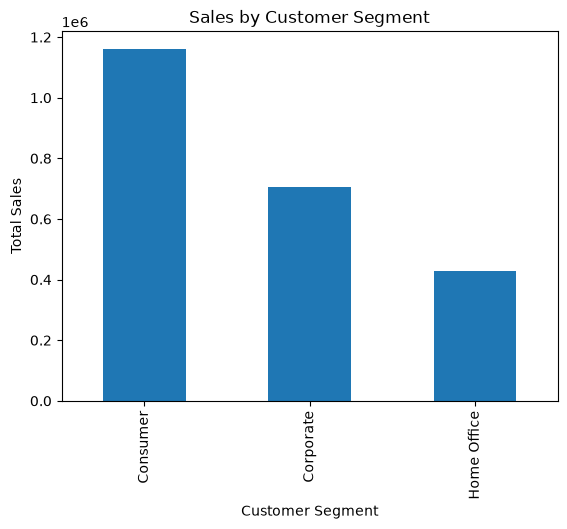

In [116]:
segment_sales.plot(kind="bar")
plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.show()

In [117]:
segment_profit = df.groupby("Segment")["Profit"].sum()
segment_profit

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

In [118]:
segment_profit.idxmax()

'Consumer'

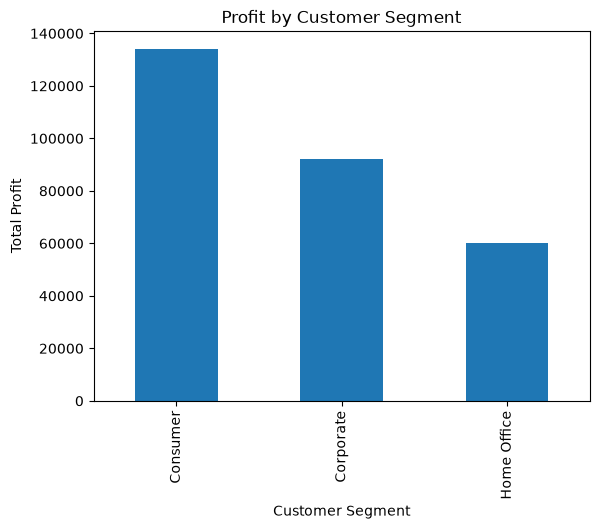

In [119]:
segment_profit.plot(kind="bar")
plt.title("Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")
plt.show()

## Discount analysis

In [125]:
discount_profit_corr = df[["Discount", "Profit"]].corr().loc["Discount", "Profit"]
discount_profit_corr

np.float64(-0.21948745637176792)

In [126]:
discount_profit = df.groupby("Discount")["Profit"].mean()
discount_profit

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

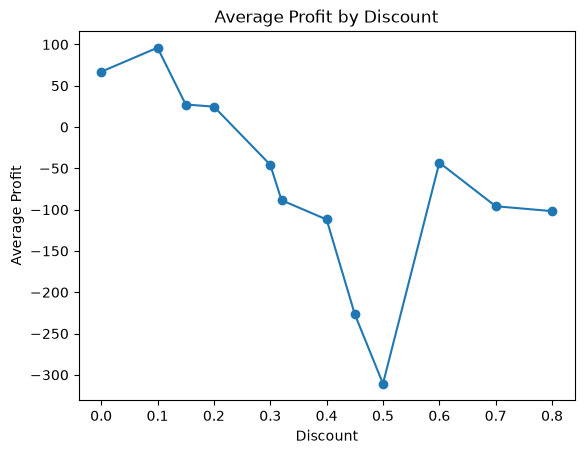

In [127]:
discount_profit.plot(kind="line", marker="o")
plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()

In [128]:
discount_profit.loc[0.80]

np.float64(-101.79679733333333)

## Higher discounts are generally associated with lower profitability in this dataset The correlation between Discount and Profit is approximately -0.22 and average profit becomes negative at several higher discount level
## Correlation does not prove that discount alone causes the losses. Product type, quantity, shipping, costs, and other factors could also contribute.

## Loss making products

In [129]:
product_profit = df.groupby("Product Name")["Profit"].sum()

## top 10 products with the biggest loss 

In [130]:
loss_products = product_profit.sort_values().head(10)
loss_products

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

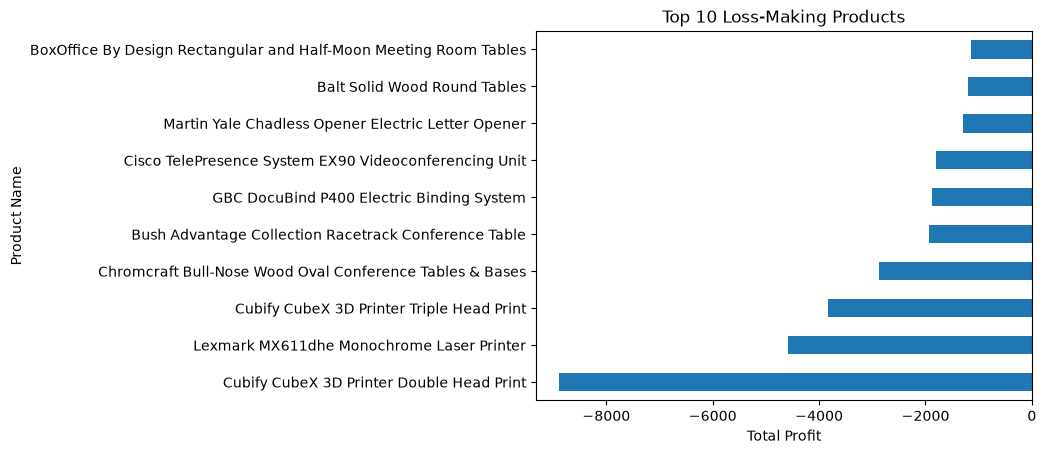

In [131]:
loss_products.plot(kind="barh")
plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")
plt.show()

## A negative bar means the company lost money overall on that product
## Possible reasons could include large discounts high costs, low selling prices, or an unfavorable product mix We won't assume the reason until we analyze it

## Key Insights & Recommendations

In [132]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100

In [133]:
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Profit Margin:", profit_margin)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Profit Margin: 12.467217240315605


In [136]:
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum()
category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [135]:
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum()
region_summary

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


## Insight 1: Total sales were approximately $2.30 million, with total profit of approximately 286K, giving an overall profit margin of 12.47%

## Insight 2: Technology generated the highest sales and profit among the three categories

## Insight 3: Furniture generated substantial sales but had a much lower profit margin (~2.49%) than Office Supplies and Technology

## Insight 4: 2017 had the highest annual sales, at approximately $733K

## Insight 5: November had the highest overall monthly sales, at approximately $352K, suggesting strong year-end seasonality

## Insight 6: Higher discounts were generally associated with lower profitability; the Discount–Profit correlation was approximately -0.22

## Insight 7: Some individual transactions had very large losses, so high sales alone should not be treated as a measure of business success

## Recommendation 1  Review Furniture profitability

## Furniture has a relatively low profit margin compared with the other categories

## The company should investigate:

## discount levels
## product costs
## pricing
## loss-making sub-categories
## Recommendation 2 Control heavy discounts

## Because higher discounts are associated with lower profit, the company should avoid automatically offering very large discounts and evaluate whether the additional sales justify the reduced margin

## Recommendation 3  Prepare for peak months

## Sales are particularly strong toward September–December, especially November

## The company could plan inventory and marketing campaigns in advance of these periods

## Recommendation 4 Focus on profitable products

## Products generating high sales but low/negative profit should be reviewed rather than judging product performance using sales alone

In [137]:
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum()
category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [138]:
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum()
region_summary

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


## Insight

## Discount and Profit show a negative relationship in the dataset.
## Higher discount levels are generally associated with lower average
## profit.

## However, correlation does not prove that discount alone causes the
## profit decline.

## Conclusion

## This project used Python, Pandas, NumPy, Matplotlib, and Seaborn to
## analyze Superstore sales data.

## The analysis identified important patterns in sales, profitability,
## customers, products, regions, time periods, and discounts.

## The results show that Technology is the strongest overall category,
## while Furniture requires attention because of its relatively low
## profitability.

## The analysis also indicates strong year-end sales and a negative
## relationship between discounts and profit.

## These findings can help management improve pricing, inventory
## planning, product strategy, and profitability.